[2026-08-21 Fiddler](https://thefiddler.substack.com/p/how-far-can-you-roll)
====================

Fiddler
-------
The path is a cycloid, so its length is 8 meters.

Extra credit
------------
The length of the path depends on the distance from the center of the wheel.  Let
$r$ be the distance from the center and $L(r)$ be the length of the path.

The probability distribution of $r$ is proportional to $r$, so the average length
is $2\int_0^1 L(r)\,r\,dr$.

Let $\theta$ be the turn angle.  Arbitrarily choose the random point's
initial angle so that it is at $x = \theta + r\sin\theta$, $y = r\cos\theta$.

$$\begin{aligned}
    L(r) &= \int_0^{2\pi} d\theta\,\sqrt{(1+r\cos\theta)^2 + r^2\sin^2\theta} \\
         &= \int_0^{2\pi} d\theta\,\sqrt{1+r^2 + 2r\cos\theta} \\
         &= 2\sqrt{1+r^2}\int_0^\pi d\theta\,\sqrt{1 + \frac{2r}{1+r^2}\cos\theta} \\
         &= 4(1+r)E\left(\frac{4r}{(r+1)^2}\right) \\
\end{aligned}$$

In [1]:
L(r) = 4*(1+r)*elliptic_ec(4*r/(r+1)^2)

And this evaluation of the average is clearly wrong (it would have been
satisfying if it evaluated to 64/9):

In [2]:
integral(2*r*L(r),r,0,1)

0

Numerically, the average evaluates to approximately 7.11 meters, which
visually makes sense when plotting the integrand:

In [3]:
numerical_integral(2*r*L(r),0,1)

(7.111111111110989, 3.410543188782468e-11)

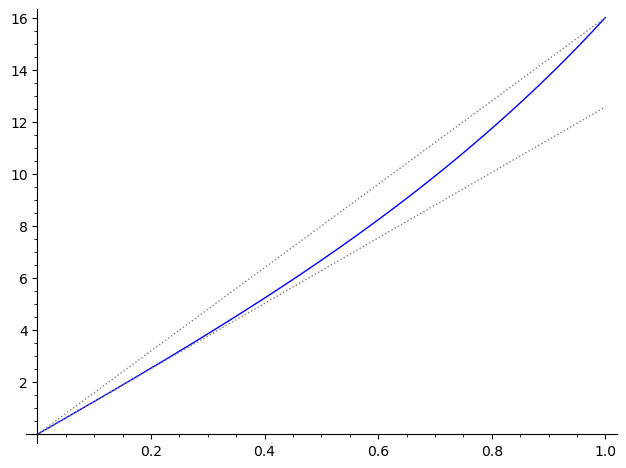

In [4]:
(plot(2*r*L(r),r,0,1)
 + plot(16*r,0,1,color="gray",linestyle="dotted")
 + plot(4*pi*r,0,1,color="gray", linestyle="dotted")
)

Alternatively, numerically evaluating the integral over $\theta$ also gives approximately 7.11 meters.

In [5]:
def Lnum(r):
    x = var("x")
    return numerical_integral(sqrt(1+r^2+2*r*cos(x)), 0, 2*pi)[0]

numerical_integral(lambda r: 2*r*Lnum(r), 0, 1)

(7.111111111134956, 2.369322662608042e-11)

Trying the substitution $x = 4r/(r+1)^2$ also gives approximately 7.11 while still failing
to give an exact result with
[Wolfram Alpha](https://www.wolframalpha.com/input?i2d=true&i=Integrate%5BEllipticE%5C%2891%29x%5C%2893%29%5C%2840%29-Divide%5B16%2CPower%5Bx%2C2%5D%5D%2BDivide%5B80%2CPower%5Bx%2C2%5DSqrt%5B1-x%5D%5D%2BDivide%5B192%2CPower%5Bx%2C3%5D%5D-Divide%5B320%2CPower%5Bx%2C3%5DSqrt%5B1-x%5D%5D-Divide%5B256%2CPower%5Bx%2C4%5D%5D%2BDivide%5B256%2CPower%5Bx%2C4%5DSqrt%5B1-x%5D%5D%5C%2841%29%2C%7Bx%2C0%2C1%7D%5D).